In [24]:
# NETTOYAGE DES DONNEES

In [25]:
# IMPORTATION DES DIFFERENTES LIBRAIRIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# CHARGEMENT DU DATASET
df = pd.read_csv(r"E:\Localhost_Academy (IA et Data Analysis)\eval_mi_parcours\data\train.csv", low_memory=False)

In [27]:
# SUPPRESSION DES LIGNES DUPLIQUEES 

print(f"=== Doublons ===")
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")

# NOMBRE DE DOUBLONS AVEC LE MEME ID
print("=============NOMBRE DE DOUBLONS SUR LA COLONNE ID=================")
doublon = df.duplicated(subset=["ID"])

=== Doublons ===
Nombre de lignes dupliquées : 0
=============NOMBRE DE DOUBLONS SUR LA COLONNE ID=================


In [28]:
## AUCUNE LIGNE DUPLIQUEE

In [29]:
# NETTOYAGE DES CARACTERES PARASITES
colonnes = ["Annual_Income", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance", "Num_of_Loan"]
for col in colonnes:
    df[col] = df[col].astype(str).str.replace("_", "")
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[colonnes]

# coerce = les valeurs non convertibles deviennent NaN pour empecher l'algorithme de planter

,Annual_Income,Outstanding_Debt,Amount_invested_monthly,Monthly_Balance,Num_of_Loan
0,19114.12,809.98,80.415295,312.494089,4
1,19114.12,809.98,118.280222,284.629162,4
2,19114.12,809.98,81.699521,331.209863,4
3,19114.12,809.98,199.458074,223.451310,4
4,19114.12,809.98,41.420153,341.489231,4
...,...,...,...,...,...
99995,39628.99,502.38,60.971333,479.866228,2
99996,39628.99,502.38,54.185950,496.651610,2
99997,39628.99,502.38,24.028477,516.809083,2
99998,39628.99,502.38,251.672582,319.164979,2


In [30]:
# CORRIGEONS LES VALEURS ABERANTES

In [31]:
# NETTOYAGE DES CARACTERES PARASITES
colonnes = ["Age", "Num_of_Delayed_Payment", "Changed_Credit_Limit"]
for col in colonnes:
    df[col] = df[col].astype(str).str.replace("_", "")
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[colonnes]

# coerce = les valeurs non convertibles deviennent NaN pour empecher l'algorithme de planter

,Age,Num_of_Delayed_Payment,Changed_Credit_Limit
0,23,7.0,11.27
1,23,NaN,11.27
2,-500,7.0,NaN
3,23,4.0,6.27
4,23,NaN,11.27
...,...,...,...
99995,25,7.0,11.50
99996,25,7.0,11.50
99997,25,6.0,11.50
99998,25,NaN,11.50


In [32]:
df["Age"] = df["Age"].clip(lower=18, upper=100)

In [33]:
df["Age"].describe()

count    100000.000000
mean         34.586040
std          13.886287
min          18.000000
25%          24.000000
50%          33.000000
75%          42.000000
max         100.000000
Name: Age, dtype: float64

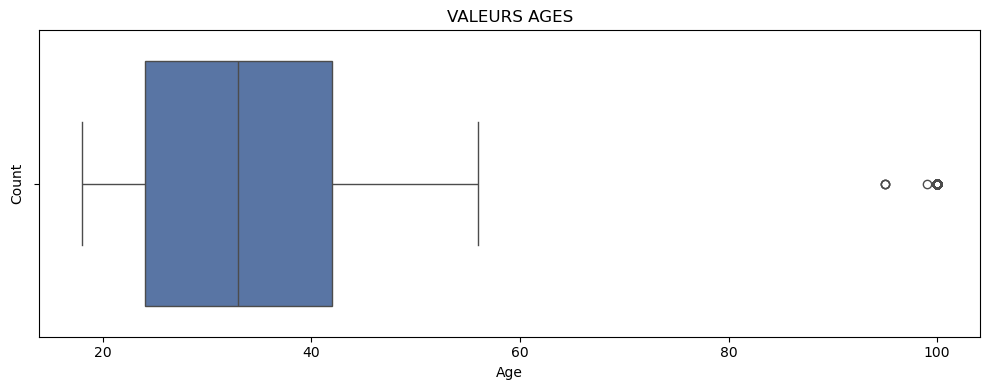

In [34]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="Age", color="#4C72B0")
plt.title("VALEURS AGES")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [35]:
df.loc[df["Num_Bank_Accounts"]<0, "Num_Bank_Accounts"] = np.nan

df["Num_Bank_Accounts"].describe()

count    99979.000000
mean        17.095080
std        117.416871
min          0.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

In [36]:
# VERIFICATION DES OUTLEURS
outlier_cols = ["Num_Bank_Accounts"]

print("=== Détection des outliers (méthode IQR) ===")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < borne_inf) | (df[col] > borne_sup)).sum()
    print(f"  {col:15s} — borne [{borne_inf:.2f} ; {borne_sup:.2f}]  |  outliers détectés : {n_outliers}")


=== Détection des outliers (méthode IQR) ===
  Num_Bank_Accounts — borne [-3.00 ; 13.00]  |  outliers détectés : 1315


In [37]:
# CORRECTION DES OUTLEURS
df.loc[(df[col] < borne_inf) | (df[col] > borne_sup), col] = np.nan
df["Num_Bank_Accounts"].describe()

count    98664.000000
mean         5.368980
std          2.592451
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         11.000000
Name: Num_Bank_Accounts, dtype: float64

In [38]:
# IMPUTATION DES VALEURS MANQUANTES

In [39]:
# CAS DES COLONNES NUMERIQUES
num_cols = df.select_dtypes(include=['number']).columns
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [40]:
# CAS DES COLONNES CATEGORIELLES
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(df[col].mode()[0])

In [41]:
# VERIFICATION VALEURS MANQUANTES
print("=== Valeurs manquantes par colonne ===")
missing = df.isnull().sum()
print(missing.sort_values(ascending=False))
print(f"\nTotal valeurs manquantes : {missing.sum()}")

=== Valeurs manquantes par colonne ===
ID                          0
Customer_ID                 0
Monthly_Balance             0
Payment_Behaviour           0
Amount_invested_monthly     0
Total_EMI_per_month         0
Payment_of_Min_Amount       0
Credit_History_Age          0
Credit_Utilization_Ratio    0
Outstanding_Debt            0
Credit_Mix                  0
Num_Credit_Inquiries        0
Changed_Credit_Limit        0
Num_of_Delayed_Payment      0
Delay_from_due_date         0
Type_of_Loan                0
Num_of_Loan                 0
Interest_Rate               0
Num_Credit_Card             0
Num_Bank_Accounts           0
Monthly_Inhand_Salary       0
Annual_Income               0
Occupation                  0
SSN                         0
Age                         0
Name                        0
Month                       0
Credit_Score                0
dtype: int64

Total valeurs manquantes : 0


In [42]:
# COMMENTAIRE
# Dans ce cas, pour ne plus creer d autres valeurs aberantes, nous avons utiliser la mediane car c'est plus robuste que la moyenne, et les valeurs manquantes etait trop peut pour etre supprimer
# Le mode pour les valeurs categorielles pour verifier que les valeurs manquantes sont remplacer par la categorie la plus frequente, et ne pouvant pas utiliser la moyenne ou la mediane car sont des caracteres

In [43]:
# EXTRACTION DE LA VALEUR NUMERIQUE ET CONVERTION DES ANNEES EN MOIS
extracted = df["Credit_History_Age"].astype(str).str.extract(r"(\d+) Years and (\d+) Months")
years = pd.to_numeric(extracted[0], errors='coerce')
months = pd.to_numeric(extracted[1], errors='coerce')
df["Credit_History_Age"] = years * 12 + months

df["Credit_History_Age"].describe()

count    100000.00000
mean        218.46876
std          95.52431
min           1.00000
25%         154.00000
50%         208.00000
75%         292.00000
max         404.00000
Name: Credit_History_Age, dtype: float64

In [49]:
# 1. Nettoyage de Payment_Behaviour
mode = df['Payment_Behaviour'].mode()[0]

df.loc[
    ~df['Payment_Behaviour'].isin([
        'Low_spent_Small_value_payments',
        'Low_spent_Medium_value_payments',
        'Low_spent_Large_value_payments',
        'High_spent_Small_value_payments',
        'High_spent_Medium_value_payments',
        'High_spent_Large_value_payments'
    ]),
    'Payment_Behaviour'
] = mode

# 2. Création de X
X = df.drop('Credit_Score', axis=1)

# 3. Encodage des variables catégorielles
X = pd.get_dummies(X, drop_first=True)

In [50]:
# SUPPRESSION DES COLONNES INUTILES
print("Colonnes invalides:", df.columns.tolist())
df = df.drop(columns=["ID", "Customer_ID", "Month", "Type_of_Loan", "Name"], errors='ignore')
df.head()

Colonnes invalides: ['Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']


,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23,821-00-0265,Scientist,19114.12,1824.843333,3.0,4,3,4,3,...,_,809.98,26.822620,265,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,23,821-00-0265,Scientist,19114.12,3093.745000,3.0,4,3,4,-1,...,Good,809.98,31.944960,191,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,18,821-00-0265,Scientist,19114.12,3093.745000,3.0,4,3,4,3,...,Good,809.98,28.609352,267,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,23,821-00-0265,Scientist,19114.12,3093.745000,3.0,4,3,4,5,...,Good,809.98,31.377862,268,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,23,821-00-0265,Scientist,19114.12,1824.843333,3.0,4,3,4,6,...,Good,809.98,24.797347,269,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


In [51]:
df.to_csv('data/train_clean.csv', index=False)

In [52]:

# Vérification finale et nettoyage complémentaire avant export

# Re imputation des colonnes numériques
num_cols = df.select_dtypes(include=['number']).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

# Re imputation des colonnes catégorielles
cat_cols = df.select_dtypes(include=['object']).columns
for c in cat_cols:
    mode = df[c].mode(dropna=True)
    if len(mode)>0:
        df[c] = df[c].fillna(mode[0])

print("Valeurs manquantes restantes :", df.isnull().sum().sum())

# Sauvegarde
df.to_csv('train_clean.csv', index=False)
print("Fichier train_clean.csv généré.")


Valeurs manquantes restantes : 0
Fichier train_clean.csv généré.
